In [1]:
#%matplotlib inline
import argparse
import os
import random
import torch
import torch.nn as nn
import torch.nn.parallel
import torch.optim as optim
import torch.utils.data
import torchvision.datasets as dset
import torchvision.transforms as transforms
import torchvision.utils as vutils
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from IPython.display import HTML

# Set random seed for reproducibility
manualSeed = 999
#manualSeed = random.randint(1, 10000) # use if you want new results
print("Random Seed: ", manualSeed)
random.seed(manualSeed)
torch.manual_seed(manualSeed)
torch.use_deterministic_algorithms(True) # Needed for reproducible results

Random Seed:  999


In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("crawford/emnist")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'emnist' dataset.
Path to dataset files: /kaggle/input/emnist


In [3]:
# Root directory for dataset
dataroot = path

# Number of workers for dataloader
workers = 2

# Batch size during training
batch_size = 128

# Spatial size of training images. All images will be resized to this
#   size using a transformer.
image_size = 64

# Number of channels in the training images. For color images this is 3
nc = 1 # Changed to 1 for grayscale images

# Size of z latent vector (i.e. size of generator input)
nz = 100

# Size of feature maps in generator
ngf = 64

# Size of feature maps in discriminator
ndf = 64

# Number of training epochs
num_epochs = 5

# Learning rate for optimizers
lr = 0.0002

# Beta1 hyperparameter for Adam optimizers
beta1 = 0.5

# Number of GPUs available. Use 0 for CPU mode.
ngpu = 1

In [4]:
#Claude wrote this when I asked it how to do it. I feel obsolete now.
"""
EMNIST Dataset for PyTorch

A custom dataset class that extends torchvision.datasets.VisionDataset
to load EMNIST data from CSV files for character recognition tasks.
"""

import os
import pandas as pd
import torch
from torch import Tensor
from torchvision.datasets import VisionDataset
from torchvision import transforms
from PIL import Image
import numpy as np
from typing import Any, Callable, Optional, Tuple, Dict, List


class EMNISTDataset(VisionDataset):
    """
    EMNIST Dataset for loading character recognition data from CSV files.

    Args:
        root (str): Root directory containing the EMNIST CSV files
        split (str): Dataset split - 'train' or 'test'
        dataset_type (str): Type of EMNIST dataset - 'balanced', 'byclass', 'bymerge',
                           'digits', 'letters', or 'mnist'
        transform (callable, optional): A function/transform to apply to the PIL image
        target_transform (callable, optional): A function/transform to apply to the target
        download (bool): Not implemented - data should be pre-downloaded
    """

    # Available dataset types
    DATASET_TYPES = ['balanced', 'byclass', 'bymerge', 'digits', 'letters', 'mnist']

    def __init__(
        self,
        root: str,
        split: str = 'train',
        dataset_type: str = 'balanced',
        transform: Optional[Callable] = None,
        target_transform: Optional[Callable] = None,
        download: bool = False,
    ) -> None:
        super().__init__(root, transform=transform, target_transform=target_transform)

        if download:
            raise NotImplementedError("Automatic download not supported. Please download EMNIST data manually.")

        if split not in ['train', 'test']:
            raise ValueError(f"Split must be 'train' or 'test', got {split}")

        if dataset_type not in self.DATASET_TYPES:
            raise ValueError(f"Dataset type must be one of {self.DATASET_TYPES}, got {dataset_type}")

        self.split = split
        self.dataset_type = dataset_type

        # Construct file paths
        self.data_file = os.path.join(root, f'emnist-{dataset_type}-{split}.csv')
        self.mapping_file = os.path.join(root, f'emnist-{dataset_type}-mapping.txt')

        # Verify files exist
        if not os.path.exists(self.data_file):
            raise FileNotFoundError(f"Data file not found: {self.data_file}")

        if not os.path.exists(self.mapping_file):
            raise FileNotFoundError(f"Mapping file not found: {self.mapping_file}")

        # Load mapping
        self.class_mapping = self._load_mapping()

        # Load data - we'll use chunked reading for large files
        print(f"Loading {dataset_type} {split} data...")
        self._load_data()
        print(f"Loaded {len(self.data)} samples")

    def _load_mapping(self) -> Dict[int, int]:
        """Load the class index to ASCII character mapping."""
        mapping = {}
        with open(self.mapping_file, 'r') as f:
            for line in f:
                parts = list(map(int, line.strip().split()))
                if len(parts) == 2:
                    # Standard format: class_idx, ascii_val
                    class_idx, ascii_val = parts
                    mapping[class_idx] = ascii_val
                elif len(parts) == 3:
                    # Letters format: class_idx, uppercase_ascii, lowercase_ascii
                    # Use the uppercase ASCII value by default
                    class_idx, uppercase_ascii, lowercase_ascii = parts
                    mapping[class_idx] = uppercase_ascii
                else:
                    raise ValueError(f"Unexpected mapping file format: {line}")
        return mapping

    def _load_data(self) -> None:
        """Load the image data and labels from CSV file."""
        # For very large files, we might want to use chunked loading
        # For now, let's load everything into memory
        try:
            # Try to load the entire file
            df = pd.read_csv(self.data_file, header=None)
            self.labels = df.iloc[:, 0].values.astype(np.int64)
            self.data = df.iloc[:, 1:].values.astype(np.uint8)

        except MemoryError:
            # If file is too large for memory, implement chunked loading
            print("File too large for memory, implementing chunked loading...")
            self._load_data_chunked()

    def _load_data_chunked(self) -> None:
        """Load data in chunks for very large files."""
        chunks = []
        labels = []

        chunk_size = 10000  # Adjust based on available memory

        for chunk in pd.read_csv(self.data_file, header=None, chunksize=chunk_size):
            labels.extend(chunk.iloc[:, 0].values)
            chunks.append(chunk.iloc[:, 1:].values)

        self.labels = np.array(labels, dtype=np.int64)
        self.data = np.vstack(chunks).astype(np.uint8)

    def __len__(self) -> int:
        """Return the number of samples in the dataset."""
        return len(self.data)

    def __getitem__(self, index: int) -> Tuple[Any, Any]:
        """
        Get a sample from the dataset.

        Args:
            index (int): Index of the sample to retrieve

        Returns:
            tuple: (image, target) where image is PIL Image and target is class index
        """
        # Get image data and reshape to 28x28
        img_data = self.data[index].reshape(28, 28)

        # EMNIST images need to be rotated 90 degrees and flipped horizontally
        # to display correctly. This is a known characteristic of the EMNIST dataset
        # where the raw pixel data is stored in a transposed format.
        img_data = np.rot90(img_data)  # Rotate 90 degrees counterclockwise
        img_data = np.rot90(img_data)  # Rotate 90 degrees counterclockwise
        img_data = np.rot90(img_data)  # Rotate 90 degrees counterclockwise
        img_data = np.fliplr(img_data)  # Flip horizontally (left-right)

        # Convert to PIL Image
        img = Image.fromarray(img_data)

        # Get target
        target = self.labels[index]

        # Apply transforms
        if self.transform is not None:
            img = self.transform(img)

        if self.target_transform is not None:
            target = self.target_transform(target)

        return img, target

    def get_ascii_char(self, class_idx: int) -> str:
        """
        Convert class index to corresponding ASCII character.

        Args:
            class_idx (int): Class index

        Returns:
            str: ASCII character
        """
        if class_idx in self.class_mapping:
            return chr(self.class_mapping[class_idx])
        else:
            raise ValueError(f"Class index {class_idx} not found in mapping")

    def get_class_names(self) -> List[str]:
        """Get list of all class names (ASCII characters)."""
        return [chr(ascii_val) for ascii_val in sorted(self.class_mapping.values())]

    def get_sample_by_class(self, class_idx: int, num_samples: int = 1) -> List[Tuple[Any, Any]]:
        """
        Get samples of a specific class.

        Args:
            class_idx (int): Target class index
            num_samples (int): Number of samples to retrieve

        Returns:
            List of (image, target) tuples
        """
        # Find indices of samples with the target class
        class_indices = np.where(self.labels == class_idx)[0]

        if len(class_indices) == 0:
            raise ValueError(f"No samples found for class {class_idx}")

        # Select random samples
        selected_indices = np.random.choice(
            class_indices,
            min(num_samples, len(class_indices)),
            replace=False
        )

        samples = []
        for idx in selected_indices:
            samples.append(self[idx])

        return samples

    def get_dataset_info(self) -> Dict[str, Any]:
        """Get information about the dataset."""
        unique_classes = np.unique(self.labels)
        class_counts = {cls: np.sum(self.labels == cls) for cls in unique_classes}

        return {
            'dataset_type': self.dataset_type,
            'split': self.split,
            'total_samples': len(self.data),
            'num_classes': len(unique_classes),
            'classes': unique_classes.tolist(),
            'class_names': [self.get_ascii_char(cls) for cls in unique_classes],
            'class_counts': class_counts,
            'image_shape': (28, 28),
            'data_type': 'grayscale'
        }


def create_transforms(normalize: bool = True, augment: bool = False) -> transforms.Compose:
    """
    Create common transforms for EMNIST data.

    Args:
        normalize (bool): Whether to normalize to [0, 1] range
        augment (bool): Whether to apply data augmentation

    Returns:
        transforms.Compose: Composed transforms
    """
    transform_list = []

    # Convert PIL to tensor
    transform_list.append(transforms.ToTensor())

    # Data augmentation (if requested)
    if augment:
        transform_list.extend([
            transforms.RandomRotation(degrees=10),
            transforms.RandomAffine(degrees=0, translate=(0.1, 0.1), scale=(0.9, 1.1))
        ])

    # Normalization
    if normalize:
        # EMNIST mean and std (computed from training data)
        transform_list.append(transforms.Normalize(mean=[0.1736], std=[0.3248]))

    return transforms.Compose(transform_list)

Loading byclass train data...
Loaded 697932 samples


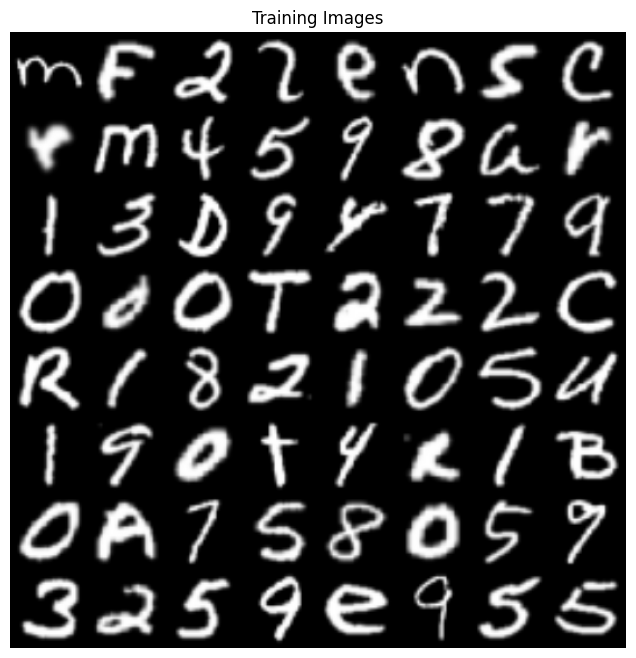

In [5]:
import torchvision.transforms as transforms

# We can use an image folder dataset the way we have it setup.
# Create the dataset
dataset = EMNISTDataset(root=dataroot,
                           split='train',
                           dataset_type='byclass',
                           transform=transforms.Compose([
                               transforms.Resize(image_size), # Resize to image_size
                               # EMNIST images are already grayscale, so no need for transforms.Grayscale if nc=1
                               transforms.ToTensor(),
                               transforms.Normalize((0.5,), (0.5,)), # Normalize for 1-channel images
                           ]))
# Create the dataloader
dataloader = torch.utils.data.DataLoader(dataset, batch_size=batch_size,
                                         shuffle=True, num_workers=workers)

# Decide which device we want to run on
device = torch.device("cuda:0" if (torch.cuda.is_available() and ngpu > 0) else "cpu")

# Plot some training images
real_batch = next(iter(dataloader))
plt.figure(figsize=(8,8))
plt.axis("off")
plt.title("Training Images")
plt.imshow(np.transpose(vutils.make_grid(real_batch[0].to(device)[:64], padding=2, normalize=True).cpu(),(1,2,0)))
plt.show()

In [6]:
# custom weights initialization called on ``netG`` and ``netD``
def weights_init(m):
    classname = m.__class__.__name__
    if classname.find('Conv') != -1:
        nn.init.normal_(m.weight.data, 0.0, 0.02)
    elif classname.find('BatchNorm') != -1:
        nn.init.normal_(m.weight.data, 1.0, 0.02)
        nn.init.constant_(m.bias.data, 0)


In [7]:
# Generator Code

class Generator(nn.Module):
    def __init__(self, ngpu):
        super(Generator, self).__init__()
        self.ngpu = ngpu
        self.main = nn.Sequential(
            # input is Z, going into a convolution
            nn.ConvTranspose2d( nz, ngf * 8, 4, 1, 0, bias=False),
            nn.BatchNorm2d(ngf * 8),
            nn.ReLU(True),
            # state size. ``(ngf*8) x 4 x 4``
            nn.ConvTranspose2d(ngf * 8, ngf * 4, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ngf * 4),
            nn.ReLU(True),
            # state size. ``(ngf*4) x 8 x 8``
            nn.ConvTranspose2d( ngf * 4, ngf * 2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ngf * 2),
            nn.ReLU(True),
            # state size. ``(ngf*2) x 16 x 16``
            nn.ConvTranspose2d( ngf * 2, ngf, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ngf),
            nn.ReLU(True),
            # state size. ``(ngf) x 32 x 32``
            nn.ConvTranspose2d( ngf, nc, 4, 2, 1, bias=False),
            nn.Tanh()
            # state size. ``(nc) x 64 x 64``
        )

    def forward(self, input):
        return self.main(input)

In [8]:
# Create the generator
netG = Generator(ngpu).to(device)

# Handle multi-GPU if desired
if (device.type == 'cuda') and (ngpu > 1):
    netG = nn.DataParallel(netG, list(range(ngpu)))

# Apply the ``weights_init`` function to randomly initialize all weights
#  to ``mean=0``, ``stdev=0.02``.
netG.apply(weights_init)

# Print the model
print(netG)

Generator(
  (main): Sequential(
    (0): ConvTranspose2d(100, 512, kernel_size=(4, 4), stride=(1, 1), bias=False)
    (1): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): ConvTranspose2d(512, 256, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (4): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU(inplace=True)
    (6): ConvTranspose2d(256, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (7): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (8): ReLU(inplace=True)
    (9): ConvTranspose2d(128, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (10): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (11): ReLU(inplace=True)
    (12): ConvTranspose2d(64, 1, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (13): Tanh()
  )
)


## Discriminator

Attention Grabber: "The DCGAN paper mentions it is a good practice to use strided convolution rather than pooling to downsample because _it lets the network learn its own pooling function."_

In [9]:
class Discriminator(nn.Module):
    def __init__(self, ngpu):
        super(Discriminator, self).__init__()
        self.ngpu = ngpu
        self.main = nn.Sequential(
            # input is ``(nc) x 64 x 64``
            nn.Conv2d(nc, ndf, 4, 2, 1, bias=False),
            nn.LeakyReLU(0.2, inplace=True),
            # state size. ``(ndf) x 32 x 32``
            nn.Conv2d(ndf, ndf * 2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ndf * 2),
            nn.LeakyReLU(0.2, inplace=True),
            # state size. ``(ndf*2) x 16 x 16``
            nn.Conv2d(ndf * 2, ndf * 4, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ndf * 4),
            nn.LeakyReLU(0.2, inplace=True),
            # state size. ``(ndf*4) x 8 x 8``
            nn.Conv2d(ndf * 4, ndf * 8, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ndf * 8),
            nn.LeakyReLU(0.2, inplace=True),
            # state size. ``(ndf*8) x 4 x 4``
            nn.Conv2d(ndf * 8, 1, 4, 1, 0, bias=False),
            nn.Sigmoid()
        )

    def forward(self, input):
        return self.main(input)

In [10]:
# Create the Discriminator
netD = Discriminator(ngpu).to(device)

# Handle multi-GPU if desired
if (device.type == 'cuda') and (ngpu > 1):
    netD = nn.DataParallel(netD, list(range(ngpu)))

# Apply the ``weights_init`` function to randomly initialize all weights
# like this: ``to mean=0, stdev=0.2``.
netD.apply(weights_init)

# Print the model
print(netD)

Discriminator(
  (main): Sequential(
    (0): Conv2d(1, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (1): LeakyReLU(negative_slope=0.2, inplace=True)
    (2): Conv2d(64, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (3): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (4): LeakyReLU(negative_slope=0.2, inplace=True)
    (5): Conv2d(128, 256, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (6): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (7): LeakyReLU(negative_slope=0.2, inplace=True)
    (8): Conv2d(256, 512, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (9): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): LeakyReLU(negative_slope=0.2, inplace=True)
    (11): Conv2d(512, 1, kernel_size=(4, 4), stride=(1, 1), bias=False)
    (12): Sigmoid()
  )
)


In [11]:
# Initialize the ``BCELoss`` function
criterion = nn.BCELoss()

# Create batch of latent vectors that we will use to visualize
#  the progression of the generator
fixed_noise = torch.randn(64, nz, 1, 1, device=device)

# Establish convention for real and fake labels during training
real_label = 1.
fake_label = 0.

# Setup Adam optimizers for both G and D
optimizerD = optim.Adam(netD.parameters(), lr=lr, betas=(beta1, 0.999))
optimizerG = optim.Adam(netG.parameters(), lr=lr, betas=(beta1, 0.999))

In [12]:
# Training Loop

# Lists to keep track of progress
img_list = []
G_losses = []
D_losses = []
iters = 0

print("Starting Training Loop...")
# For each epoch
for epoch in range(num_epochs):
    # For each batch in the dataloader
    for i, data in enumerate(dataloader, 0):

        ############################
        # (1) Update D network: maximize log(D(x)) + log(1 - D(G(z)))
        ###########################
        ## Train with all-real batch
        netD.zero_grad()
        # Format batch
        real_cpu = data[0].to(device)
        b_size = real_cpu.size(0)
        label = torch.full((b_size,), real_label, dtype=torch.float, device=device)
        # Forward pass real batch through D
        output = netD(real_cpu).view(-1)
        # Calculate loss on all-real batch
        errD_real = criterion(output, label)
        # Calculate gradients for D in backward pass
        errD_real.backward()
        D_x = output.mean().item()

        ## Train with all-fake batch
        # Generate batch of latent vectors
        noise = torch.randn(b_size, nz, 1, 1, device=device)
        # Generate fake image batch with G
        fake = netG(noise)
        label.fill_(fake_label)
        # Classify all fake batch with D
        output = netD(fake.detach()).view(-1)
        # Calculate D's loss on the all-fake batch
        errD_fake = criterion(output, label)
        # Calculate the gradients for this batch, accumulated (summed) with previous gradients
        errD_fake.backward()
        D_G_z1 = output.mean().item()
        # Compute error of D as sum over the fake and the real batches
        errD = errD_real + errD_fake
        # Update D
        optimizerD.step()

        ############################
        # (2) Update G network: maximize log(D(G(z)))
        ###########################
        netG.zero_grad()
        label.fill_(real_label)  # fake labels are real for generator cost
        # Since we just updated D, perform another forward pass of all-fake batch through D
        output = netD(fake).view(-1)
        # Calculate G's loss based on this output
        errG = criterion(output, label)
        # Calculate gradients for G
        errG.backward()
        D_G_z2 = output.mean().item()
        # Update G
        optimizerG.step()

        # Output training stats
        if i % 50 == 0:
            print('[%d/%d][%d/%d]\tLoss_D: %.4f\tLoss_G: %.4f\tD(x): %.4f\tD(G(z)): %.4f / %.4f'
                  % (epoch, num_epochs, i, len(dataloader),
                     errD.item(), errG.item(), D_x, D_G_z1, D_G_z2))

        # Save Losses for plotting later
        G_losses.append(errG.item())
        D_losses.append(errD.item())

        # Check how the generator is doing by saving G's output on fixed_noise
        if (iters % 500 == 0) or ((epoch == num_epochs-1) and (i == len(dataloader)-1)):
            with torch.no_grad():
                fake = netG(fixed_noise).detach().cpu()
            img_list.append(vutils.make_grid(fake, padding=2, normalize=True))

        iters += 1

Starting Training Loop...
[0/5][0/5453]	Loss_D: 1.4134	Loss_G: 5.0588	D(x): 0.6122	D(G(z)): 0.5140 / 0.0095
[0/5][50/5453]	Loss_D: 0.0080	Loss_G: 9.8499	D(x): 0.9925	D(G(z)): 0.0001 / 0.0001
[0/5][100/5453]	Loss_D: 0.0257	Loss_G: 6.5579	D(x): 0.9897	D(G(z)): 0.0148 / 0.0020
[0/5][150/5453]	Loss_D: 0.0128	Loss_G: 7.2822	D(x): 0.9982	D(G(z)): 0.0108 / 0.0008
[0/5][200/5453]	Loss_D: 0.0047	Loss_G: 7.3517	D(x): 0.9991	D(G(z)): 0.0038 / 0.0007
[0/5][250/5453]	Loss_D: 0.0032	Loss_G: 7.2563	D(x): 0.9998	D(G(z)): 0.0030 / 0.0008
[0/5][300/5453]	Loss_D: 0.0024	Loss_G: 7.2053	D(x): 0.9994	D(G(z)): 0.0019 / 0.0008
[0/5][350/5453]	Loss_D: 0.0018	Loss_G: 7.3177	D(x): 0.9994	D(G(z)): 0.0013 / 0.0007
[0/5][400/5453]	Loss_D: 0.0010	Loss_G: 7.7978	D(x): 0.9998	D(G(z)): 0.0008 / 0.0005
[0/5][450/5453]	Loss_D: 0.0015	Loss_G: 7.3529	D(x): 0.9997	D(G(z)): 0.0012 / 0.0007
[0/5][500/5453]	Loss_D: 0.0014	Loss_G: 7.3456	D(x): 0.9998	D(G(z)): 0.0012 / 0.0007
[0/5][550/5453]	Loss_D: 0.0011	Loss_G: 7.5012	D(x): 0

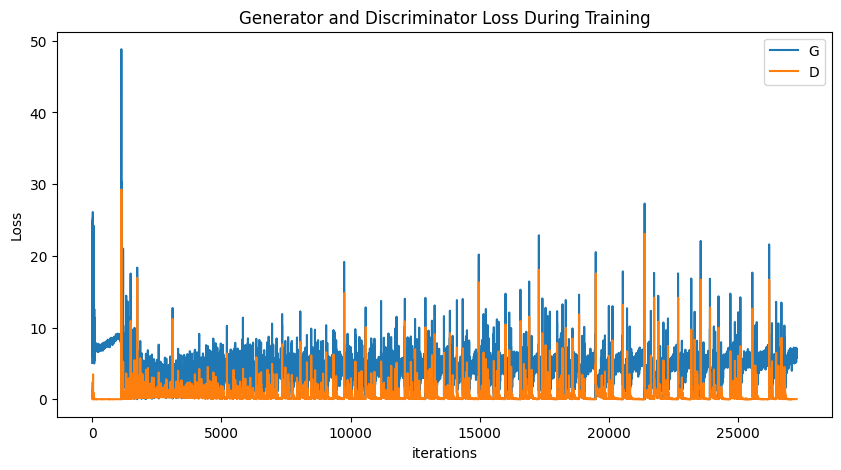

In [13]:
plt.figure(figsize=(10,5))
plt.title("Generator and Discriminator Loss During Training")
plt.plot(G_losses,label="G")
plt.plot(D_losses,label="D")
plt.xlabel("iterations")
plt.ylabel("Loss")
plt.legend()
plt.show()

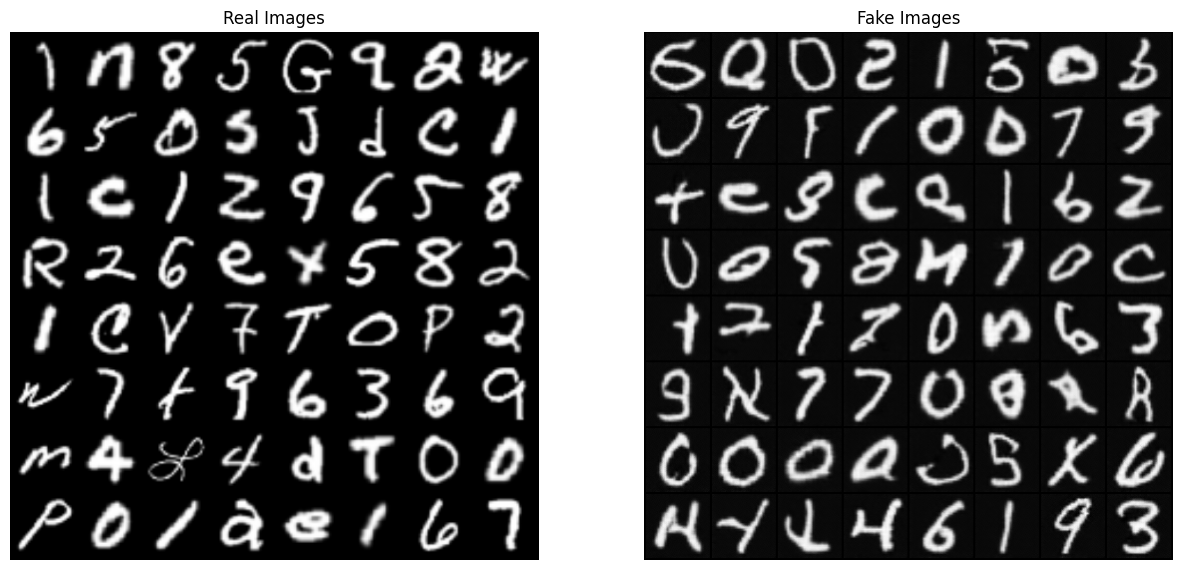

In [14]:
# Grab a batch of real images from the dataloader
real_batch = next(iter(dataloader))

# Plot the real images
plt.figure(figsize=(15,15))
plt.subplot(1,2,1)
plt.axis("off")
plt.title("Real Images")
plt.imshow(np.transpose(vutils.make_grid(real_batch[0].to(device)[:64], padding=5, normalize=True).cpu(),(1,2,0)))

# Plot the fake images from the last epoch
plt.subplot(1,2,2)
plt.axis("off")
plt.title("Fake Images")
plt.imshow(np.transpose(img_list[-1],(1,2,0)))
plt.show()